In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn tensorflow

In [12]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')
print("All imports successful")

All imports successful


In [2]:
# ── Load ──────────────────────────────────────────────────────────
df = pd.read_csv('dataset1.csv')

print("Original shape:", df.shape)
print("\nAll columns:")
print(df.columns.tolist())

Original shape: (235795, 55)

All columns:
['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


In [3]:
# ── Identify the URL column and label column ──────────────────────
# The dataset uses 'URL' and 'label' — verify this matches yours
print("\nChecking column names...")

url_col_candidates   = [c for c in df.columns if 'url' in c.lower()]
label_col_candidates = [c for c in df.columns if 'label' in c.lower() 
                        or 'class' in c.lower() or 'phish' in c.lower()]

print("URL column candidates  :", url_col_candidates)
print("Label column candidates:", label_col_candidates)

# Set these based on the output above
URL_COL   = 'URL'     # change if different e.g. 'url', 'URL_string'
LABEL_COL = 'label'   # change if different e.g. 'Label', 'class', 'phishing'


Checking column names...
URL column candidates  : ['URL', 'URLLength', 'URLSimilarityIndex', 'URLCharProb', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'URLTitleMatchScore', 'NoOfURLRedirect']
Label column candidates: ['label']


In [5]:
# ── Drop ALL columns except raw URL and label ─────────────────────
# This is the single most important step to fix the 100% accuracy problem.
# Every other column in PhiUSIIL was computed using knowledge of whether
# the URL is phishing — keeping them causes perfect but fake accuracy.

df_clean = df[[URL_COL, LABEL_COL]].copy()
df_clean.columns = ['URL', 'label']   # standardise names

# Drop rows where URL is missing
df_clean = df_clean.dropna(subset=['URL'])
df_clean['URL'] = df_clean['URL'].astype(str)

print("Clean dataframe shape:", df_clean.shape)
print("\nLabel distribution:")
print(df_clean['label'].value_counts())
print("\nLabel dtype:", df_clean['label'].dtype)

Clean dataframe shape: (235795, 2)

Label distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Label dtype: int64


In [6]:
# ── Fix label encoding ────────────────────────────────────────────
# PhiUSIIL uses 1 = phishing, 0 = legitimate (already numeric)
# But if yours has strings, this handles it automatically

if df_clean['label'].dtype == object:
    # String labels — map to 0/1
    unique_labels = df_clean['label'].unique()
    print("String labels found:", unique_labels)
    # Assume the one containing 'phish' = 1, other = 0
    phish_label = [l for l in unique_labels if 'phish' in str(l).lower()]
    if phish_label:
        df_clean['label'] = (df_clean['label'] == phish_label[0]).astype(int)
    else:
        # Fall back to LabelEncoder
        le = LabelEncoder()
        df_clean['label'] = le.fit_transform(df_clean['label'])
    print("After encoding:", df_clean['label'].value_counts())
else:
    print("Labels are already numeric — good.")
    # Make sure they are exactly 0 and 1
    unique_vals = sorted(df_clean['label'].unique())
    print("Unique label values:", unique_vals)

Labels are already numeric — good.
Unique label values: [np.int64(0), np.int64(1)]


In [7]:
def extract_url_features(url):
    """
    Derives 21 features from the raw URL string only.
    No external lookups, no page fetching, no post-labeling stats.
    Safe to use on any unseen URL at inference time.
    """
    url = str(url).strip()

    # Parse URL safely
    try:
        parsed   = urlparse(url)
        hostname = parsed.hostname or ''
        path     = parsed.path     or ''
        query    = parsed.query    or ''
    except Exception:
        hostname, path, query = '', '', ''

    # Split into words/tokens
    tokens = re.split(r'\W+', url)
    tokens = [t for t in tokens if t]

    feats = {
        # ── Length features ──────────────────────────────
        'url_length':        len(url),
        'hostname_length':   len(hostname),
        'path_length':       len(path),
        'query_length':      len(query),

        # ── Count features ───────────────────────────────
        'num_dots':          url.count('.'),
        'num_hyphens':       url.count('-'),
        'num_slashes':       url.count('/'),
        'num_at':            url.count('@'),
        'num_question':      url.count('?'),
        'num_equals':        url.count('='),
        'num_ampersand':     url.count('&'),
        'num_percent':       url.count('%'),
        'num_digits':        sum(c.isdigit() for c in url),
        'num_subdomains':    hostname.count('.'),
        'url_depth':         len([p for p in path.split('/') if p]),

        # ── Ratio features ───────────────────────────────
        'digit_ratio':       sum(c.isdigit() for c in url) / (len(url) + 1),
        'letter_ratio':      sum(c.isalpha() for c in url) / (len(url) + 1),

        # ── Boolean flags (0 or 1) ───────────────────────
        'has_https':         int(url.lower().startswith('https')),
        'has_ip':            int(bool(re.match(
                                 r'^https?://\d{1,3}(\.\d{1,3}){3}', url))),
        'has_double_slash':  int('//' in path),
        'has_hex_encoding':  int('%' in url and
                                 bool(re.search(r'%[0-9a-fA-F]{2}', url))),
        'has_shortener':     int(bool(re.search(
                                 r'(bit\.ly|goo\.gl|tinyurl|t\.co|ow\.ly|'
                                 r'is\.gd|buff\.ly|adf\.ly)', url))),
        'longest_word':      max((len(w) for w in tokens), default=0),
    }
    return feats

# Test on one URL first
test = extract_url_features("https://www.google.com/search?q=test")
print("Feature count:", len(test))
print("Sample features:", test)

Feature count: 23
Sample features: {'url_length': 36, 'hostname_length': 14, 'path_length': 7, 'query_length': 6, 'num_dots': 2, 'num_hyphens': 0, 'num_slashes': 3, 'num_at': 0, 'num_question': 1, 'num_equals': 1, 'num_ampersand': 0, 'num_percent': 0, 'num_digits': 0, 'num_subdomains': 2, 'url_depth': 1, 'digit_ratio': 0.0, 'letter_ratio': 0.7567567567567568, 'has_https': 1, 'has_ip': 0, 'has_double_slash': 0, 'has_hex_encoding': 0, 'has_shortener': 0, 'longest_word': 6}


In [8]:
# ── Apply to full dataset ─────────────────────────────────────────
print("Extracting features... (may take 1–3 minutes for large datasets)")

feature_df = df_clean['URL'].apply(extract_url_features).apply(pd.Series)

print("Feature matrix shape:", feature_df.shape)
print("Any NaN values?", feature_df.isnull().sum().sum())

# Fill any NaN with 0 (safe for all our features)
feature_df = feature_df.fillna(0)

# Final arrays
X = feature_df.values.astype(np.float32)
y = df_clean['label'].values.astype(int)

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("Class balance — 0 (legit):", (y==0).sum(), " | 1 (phishing):", (y==1).sum())

Extracting features... (may take 1–3 minutes for large datasets)
Feature matrix shape: (235795, 23)
Any NaN values? 0

X shape: (235795, 23)
y shape: (235795,)
Class balance — 0 (legit): 100945  | 1 (phishing): 134850


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # ensures same class ratio in both splits
)

# Fit scaler on training data ONLY — never on full dataset
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size : {X_train.shape[0]:,}")
print(f"Test size  : {X_test.shape[0]:,}")
print(f"Train phishing % : {y_train.mean():.2%}")
print(f"Test  phishing % : {y_test.mean():.2%}")

Train size : 188,636
Test size  : 47,159
Train phishing % : 57.19%
Test  phishing % : 57.19%


In [13]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),

    'Random Forest':       RandomForestClassifier(n_estimators=100,
                                                   n_jobs=-1,
                                                   random_state=42),

    'XGBoost':             xgb.XGBClassifier(n_estimators=100,
                                              eval_metric='logloss',
                                              use_label_encoder=False,
                                              random_state=42),

    # LinearSVC — same idea as SVM but O(n) speed, finishes in seconds
    'Linear SVM':          CalibratedClassifierCV(
                               LinearSVC(max_iter=2000, random_state=42)
                           ),

    'KNN':                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

results = {}

for name, model in models.items():
    print(f"Training: {name} ...", end=' ', flush=True)
    model.fit(X_train_sc, y_train)

    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Accuracy': acc,
        'ROC-AUC':  auc,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'model':    model,
    }
    print(f"Acc={acc:.4f}  AUC={auc:.4f}")

print("\nAll models done.")

Training: Logistic Regression ... Acc=0.9932  AUC=0.9964
Training: Random Forest ... Acc=0.9956  AUC=0.9972
Training: XGBoost ... Acc=0.9959  AUC=0.9980
Training: Linear SVM ... Acc=0.9933  AUC=0.9961
Training: KNN ... Acc=0.9955  AUC=0.9967

All models done.


In [14]:
# Summary table
summary = pd.DataFrame({
    name: {'Accuracy': v['Accuracy'], 'ROC-AUC': v['ROC-AUC']}
    for name, v in results.items()
}).T.sort_values('ROC-AUC', ascending=False)

print("=== ML Model Comparison ===")
print(summary.round(4))

best_ml_name = summary.index[0]
print(f"\nBest model: {best_ml_name}")

=== ML Model Comparison ===
                     Accuracy  ROC-AUC
XGBoost                0.9959   0.9980
Random Forest          0.9956   0.9972
KNN                    0.9955   0.9967
Logistic Regression    0.9932   0.9964
Linear SVM             0.9933   0.9961

Best model: XGBoost


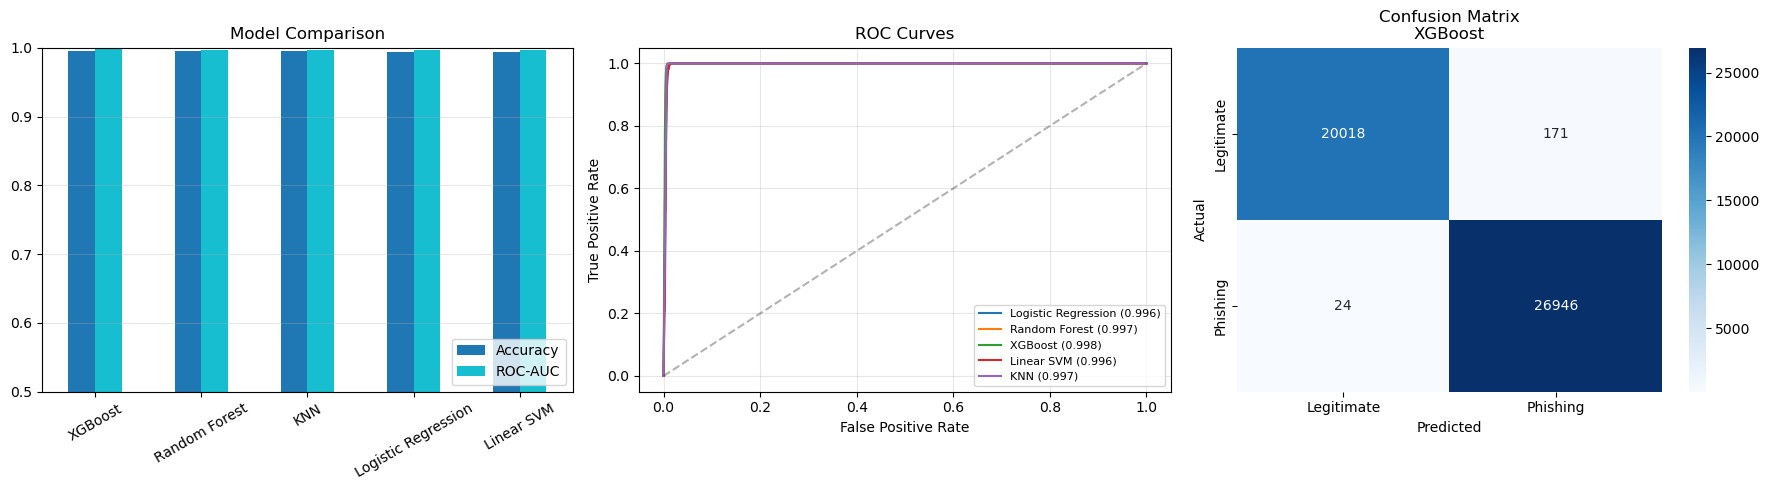

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart
summary[['Accuracy','ROC-AUC']].plot(kind='bar', ax=axes[0],
                                      rot=30, colormap='tab10')
axes[0].set_title('Model Comparison')
axes[0].set_ylim(0.5, 1.0)
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend(loc='lower right')

# ROC curves
for name, v in results.items():
    fpr, tpr, _ = roc_curve(y_test, v['y_proba'])
    axes[1].plot(fpr, tpr, label=f"{name} ({v['ROC-AUC']:.3f})")
axes[1].plot([0,1],[0,1],'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# Confusion matrix — best model
cm = confusion_matrix(y_test, results[best_ml_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Legitimate','Phishing'],
            yticklabels=['Legitimate','Phishing'])
axes[2].set_title(f'Confusion Matrix\n{best_ml_name}')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

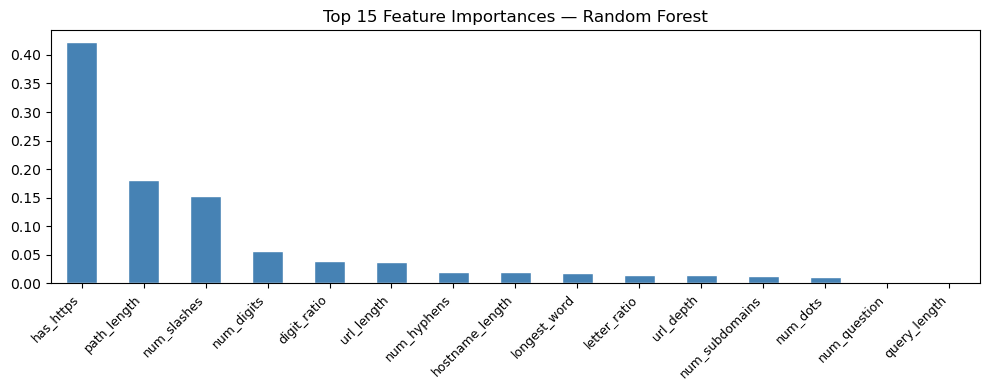


Detailed Report — XGBoost:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      1.00     20189
    Phishing       0.99      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [16]:
# Feature importance — Random Forest
rf = results['Random Forest']['model']
feat_imp = pd.Series(rf.feature_importances_,
                     index=feature_df.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 4))
feat_imp.head(15).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

# Detailed classification report
print(f"\nDetailed Report — {best_ml_name}:")
print(classification_report(y_test, results[best_ml_name]['y_pred'],
                             target_names=['Legitimate','Phishing']))

In [17]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import (Embedding, Bidirectional, LSTM,
                                          GlobalMaxPooling1D, Dense, Dropout)
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    print("TensorFlow version:", tf.__version__)
except ImportError:
    print("Run:  pip install tensorflow")
    raise

TensorFlow version: 2.21.0


In [18]:
MAX_LEN    = 200
VOCAB_SIZE = 128

def url_to_chars(url, max_len=MAX_LEN):
    return [min(ord(c), VOCAB_SIZE - 1) for c in str(url).strip()[:max_len]]

print("Encoding URLs as character sequences...")
sequences = df_clean['URL'].apply(url_to_chars).tolist()
X_seq = pad_sequences(sequences, maxlen=MAX_LEN,
                       padding='post', truncating='post', dtype='int32')
y_seq = df_clean['label'].values.astype(int)

X_seq_train, X_seq_test, y_seq_train, y_seq_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)
print(f"DL Train: {X_seq_train.shape}  |  DL Test: {X_seq_test.shape}")

Encoding URLs as character sequences...
DL Train: (188636, 200)  |  DL Test: (47159, 200)


In [19]:
def build_model():
    model = Sequential([
        Embedding(input_dim=VOCAB_SIZE, output_dim=32, input_length=MAX_LEN),
        Bidirectional(LSTM(64, return_sequences=True)),
        GlobalMaxPooling1D(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid'),
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

lstm_model = build_model()
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, verbose=1),
]

history = lstm_model.fit(
    X_seq_train, y_seq_train,
    epochs=15,
    batch_size=256,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
664/664 ━━━━━━━━━━━━━━━━━━━━ 190s 282ms/step - accuracy: 0.9781 - loss: 0.0688 - val_accuracy: 0.9972 - val_loss: 0.0162 - learning_rate: 0.0010
Epoch 2/15
664/664 ━━━━━━━━━━━━━━━━━━━━ 195s 293ms/step - accuracy: 0.9825 - loss: 0.0583 - val_accuracy: 0.9969 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 3/15
664/664 ━━━━━━━━━━━━━━━━━━━━ 187s 282ms/step - accuracy: 0.9976 - loss: 0.0170 - val_accuracy: 0.9975 - val_loss: 0.0154 - learning_rate: 0.0010
Epoch 4/15
664/664 ━━━━━━━━━━━━━━━━━━━━ 191s 287ms/step - accuracy: 0.9978 - loss: 0.0149 - val_accuracy: 0.9975 - val_loss: 0.0138 - learning_rate: 0.0010
Epoch 5/15
664/664 ━━━━━━━━━━━━━━━━━━━━ 187s 282ms/step - accuracy: 0.9810 - loss: 0.0700 - val_accuracy: 0.9926 - val_loss: 0.0299 - learning_rate: 0.0010
Epoch 6/15
664/664 ━━━━━━━━━━━━━━━━━━━━ 187s 282ms/step - accuracy: 0.9954 - loss: 0.0233 - val_accuracy: 0.9976 - val_loss: 0.0134 - learning_rate: 0.0010
Epoch 7/15
664/664 ━━━━━━━━━━━━━━━━━━━━ 192s 289ms/step - accura

185/185 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step
LSTM Accuracy : 0.9977
LSTM ROC-AUC  : 0.9986
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     20189
    Phishing       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



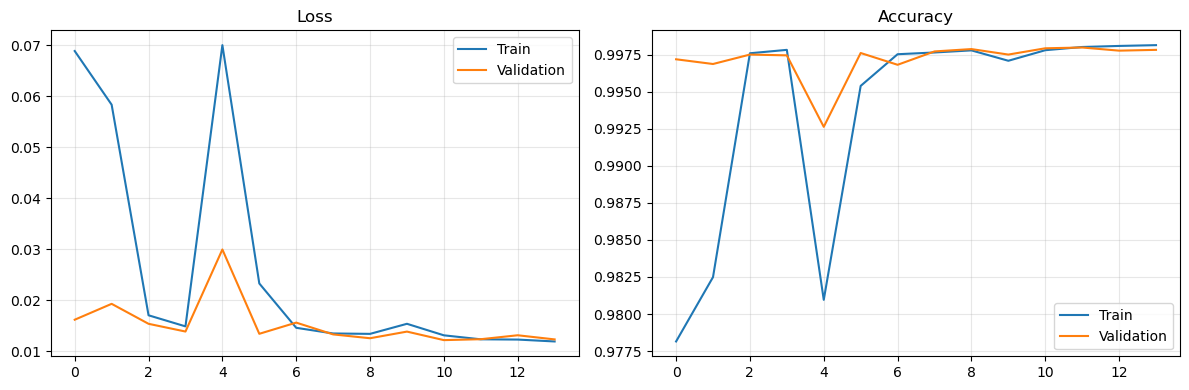

In [21]:
y_lstm_proba = lstm_model.predict(X_seq_test, batch_size=256).flatten()
y_lstm_pred  = (y_lstm_proba > 0.5).astype(int)

lstm_acc = accuracy_score(y_seq_test, y_lstm_pred)
lstm_auc = roc_auc_score(y_seq_test, y_lstm_proba)

print(f"LSTM Accuracy : {lstm_acc:.4f}")
print(f"LSTM ROC-AUC  : {lstm_auc:.4f}")
print(classification_report(y_seq_test, y_lstm_pred,
                             target_names=['Legitimate','Phishing']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [22]:
final = {name: {'Accuracy': v['Accuracy'], 'ROC-AUC': v['ROC-AUC']}
         for name, v in results.items()}
final['LSTM (Deep Learning)'] = {'Accuracy': lstm_acc, 'ROC-AUC': lstm_auc}

final_df = pd.DataFrame(final).T.sort_values('ROC-AUC', ascending=False)
print("=" * 45)
print("      FINAL MODEL COMPARISON")
print("=" * 45)
print(final_df.round(4))

      FINAL MODEL COMPARISON
                      Accuracy  ROC-AUC
LSTM (Deep Learning)    0.9977   0.9986
XGBoost                 0.9959   0.9980
Random Forest           0.9956   0.9972
KNN                     0.9955   0.9967
Logistic Regression     0.9932   0.9964
Linear SVM              0.9933   0.9961


In [23]:
import joblib
joblib.dump(scaler, 'scaler.pkl')

def predict_url(url):
    url = str(url).strip()

    # ML prediction
    feats   = extract_url_features(url)
    feat_sc = scaler.transform([list(feats.values())])
    ml_prob = results[best_ml_name]['model'].predict_proba(feat_sc)[0][1]
    ml_label = 'PHISHING' if ml_prob > 0.5 else 'Legitimate'

    # LSTM prediction
    seq_padded = pad_sequences([url_to_chars(url)], maxlen=MAX_LEN,
                                padding='post', truncating='post')
    dl_prob  = float(lstm_model.predict(seq_padded, verbose=0)[0][0])
    dl_label = 'PHISHING' if dl_prob > 0.5 else 'Legitimate'

    print(f"\nURL : {url}")
    print(f"  {best_ml_name:<22} → {ml_label:<12} confidence: {max(ml_prob,1-ml_prob):.1%}")
    print(f"  {'LSTM':<22} → {dl_label:<12} confidence: {max(dl_prob,1-dl_prob):.1%}")

test_urls = [
    "https://www.google.com/search?q=python",
    "https://github.com/scikit-learn/scikit-learn",
    "http://192.168.1.1/secure-login/paypal-verify.php",
    "http://bit.ly/3xK9f2a",
    "https://accounts.google.com-login.verify-secure.xyz/signin",
    "http://paypa1.com/account/suspended/verify-now",
]

for u in test_urls:
    predict_url(u)


URL : https://www.google.com/search?q=python
  XGBoost                → Legitimate   confidence: 99.7%
  LSTM                   → Legitimate   confidence: 100.0%

URL : https://github.com/scikit-learn/scikit-learn
  XGBoost                → Legitimate   confidence: 100.0%
  LSTM                   → Legitimate   confidence: 100.0%

URL : http://192.168.1.1/secure-login/paypal-verify.php
  XGBoost                → Legitimate   confidence: 100.0%
  LSTM                   → Legitimate   confidence: 100.0%

URL : http://bit.ly/3xK9f2a
  XGBoost                → Legitimate   confidence: 100.0%
  LSTM                   → Legitimate   confidence: 100.0%

URL : https://accounts.google.com-login.verify-secure.xyz/signin
  XGBoost                → Legitimate   confidence: 81.9%
  LSTM                   → Legitimate   confidence: 100.0%

URL : http://paypa1.com/account/suspended/verify-now
  XGBoost                → Legitimate   confidence: 100.0%
  LSTM                   → Legitimate   confidenc

In [25]:
import joblib

# Save ML model and scaler
joblib.dump(results[best_ml_name]['model'], 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save LSTM in new keras format (no warning)
lstm_model.save('lstm_model.keras')

# Save best model name
with open('best_model_name.txt', 'w') as f:
    f.write(best_ml_name)

print("All files saved.")

# Show exactly where files are saved
import os
print("\nFiles saved in this folder:")
print(os.getcwd())
print("\nFiles present:")
for f in ['model.pkl', 'scaler.pkl', 'lstm_model.keras', 'best_model_name.txt']:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) // 1024 if exists else 0
    print(f"  {f:30s} {'OK' if exists else 'MISSING'}  {size} KB")

All files saved.

Files saved in this folder:
/Users/nandinibhatia/Desktop/sample_project/fraud-detection-project

Files present:
  model.pkl                      OK  207 KB
  scaler.pkl                     OK  1 KB
  lstm_model.keras               OK  804 KB
  best_model_name.txt            OK  0 KB
